In [17]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [18]:
import os
os.listdir("data")

['mnist12x12_trainlabels.npy',
 'mnist12x12_testfeats.npy',
 'mnist12x12_trainfeats.npy',
 'mnist12x12_testlabels.npy']

In [19]:
import numpy as np

X_train = np.load("data/mnist12x12_trainfeats.npy")
y_train = np.load("data/mnist12x12_trainlabels.npy")
X_test = np.load("data/mnist12x12_testfeats.npy")
y_test = np.load("data/mnist12x12_testlabels.npy")

In [20]:
print(X_train.shape)  # should be (n_samples, 144)
print(y_train.shape)  # should be (n_samples,)

(60000, 144)
(60000,)


In [21]:
from sklearn.neural_network import MLPClassifier
##### Problem 4 ###########
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    solver="adam",
    learning_rate_init=0.001,
    batch_size=64,
    random_state=42
)
mlp.fit(X_train, y_train)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,64
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


In [22]:
from sklearn.metrics import accuracy_score
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9744


I loaded the dataset from the provided NumPy files, where each image is represented as a 144-dimensional vector corresponding 
to a 12×12 image. I trained a multilayer perceptron classifier with one hidden layer of 100 neurons using the Adam optimizer, 
a learning rate of 0.001, batch size of 64, and 300 iterations. I evaluated the model on the test set using accuracy.

In [23]:
good_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    solver="adam",
    learning_rate_init=0.001,
    batch_size=64,
    random_state=42
)

good_mlp.fit(X_train, y_train)
good_train_acc = accuracy_score(y_train, good_mlp.predict(X_train))
good_test_acc = accuracy_score(y_test, good_mlp.predict(X_test))

print(good_train_acc, good_test_acc)

0.9935666666666667 0.9744


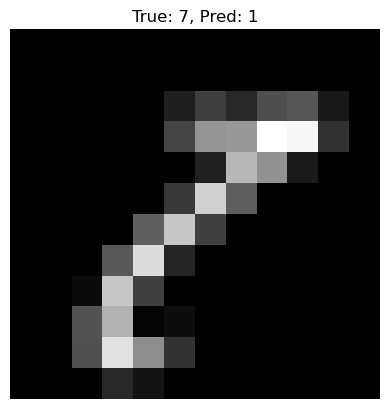

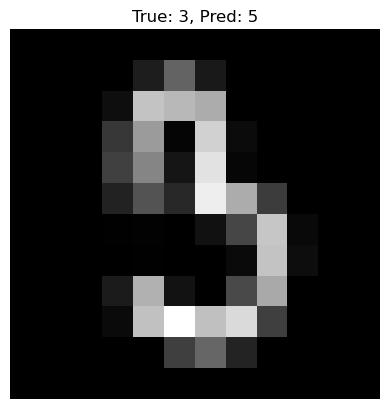

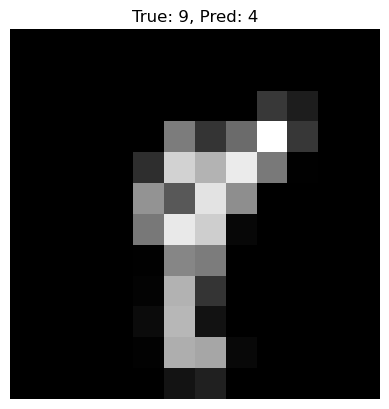

In [24]:
import matplotlib.pyplot as plt

incorrect_indices = np.where(good_mlp.predict(X_test) != y_test)[0]
random_wrong = np.random.choice(incorrect_indices, size=3, replace=False)

for idx in random_wrong:
    plt.figure()
    plt.imshow(X_test[idx].reshape(12, 12), cmap="gray")
    plt.title(f"True: {y_test[idx]}, Pred: {good_mlp.predict(X_test)[idx]}")
    plt.axis("off")
    plt.show()

In [25]:
bad_mlp = MLPClassifier(
    hidden_layer_sizes=(1,),  
    max_iter=1,
    solver="sgd",
    learning_rate_init=10,    
    batch_size=1,
    random_state=42
)
bad_mlp.fit(X_train, y_train)
bad_train_acc = accuracy_score(y_train, bad_mlp.predict(X_train))
bad_test_acc = accuracy_score(y_test, bad_mlp.predict(X_test))

print(bad_train_acc, bad_test_acc)

0.09915 0.1009


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


For the model that performed well, I used one hidden layer with 100 neurons, the Adam solver, a learning rate of 0.001, batch size of 64, and 300 maximum iterations. This model worked well because it had enough training time and used a reasonable learning rate, allowing it to learn patterns in the digit images. The training accuracy was 0.994 and the test accuracy was 0.974.
For the poor model, I kept the same network architecture but changed the training parameters. I used the SGD solver, a very large learning rate of 10, batch size of 1, and only 1 training iteration, along with a much smaller hidden layer. This model performed very poorly, with a training accuracy of 0.099 and a test accuracy of 0.101, which is close to random guessing (around 10% for 10 classes). This shows that poor parameter choices can prevent the model from learning meaningful patterns.